In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
TOP_N = 10
DATA_BASE_PATH = Path("./data")

In [3]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

In [4]:
gold = pd.read_csv(gold_file_path, sep=";", encoding="utf-8", parse_dates=["timestamp"])
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...


In [5]:
gold.describe()

,timestamp,open,high,low,close,volume
count,6177,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000
mean,2012-12-29 00:01:09.936862464,1181.017241,1186.953392,1174.885090,1181.012304,4298.049377
min,2000-08-30 00:00:00,255.000000,256.100000,255.000000,255.100000,0.000000
25%,2006-11-09 00:00:00,636.500000,640.200000,634.000000,635.200000,21.000000
50%,2012-12-31 00:00:00,1238.200000,1243.900000,1231.800000,1238.400000,108.000000
75%,2019-02-25 00:00:00,1641.300000,1652.200000,1630.400000,1640.300000,415.000000
max,2025-04-14 00:00:00,3215.500000,3235.000000,3194.500000,3222.200000,386334.000000
std,NaN,606.257425,609.741360,602.902334,606.424369,24281.911885


In [6]:
gold.sort_values("timestamp", ascending=True, inplace=True)

In [7]:
gold["currency"].value_counts()

currency
usd    6177
Name: count, dtype: int64

In [8]:
gold["unit"].value_counts()

unit
ounce    6177
Name: count, dtype: int64

In [9]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6177 non-null   datetime64[ns]
 1   open       6177 non-null   float64       
 2   high       6177 non-null   float64       
 3   low        6177 non-null   float64       
 4   close      6177 non-null   float64       
 5   volume     6177 non-null   int64         
 6   currency   6177 non-null   object        
 7   unit       6177 non-null   object        
 8   headlines  6177 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 434.4+ KB


In [10]:
gold["day_variation"] = gold["open"] - gold["close"]
gold["max_diff"] = gold["high"] - gold["low"]

In [11]:
gold[["day_variation", "max_diff"]].describe()

,day_variation,max_diff
count,6177.000000,6177.000000
mean,0.004938,12.068302
std,12.019223,13.161586
min,-90.700000,-1.300000
25%,-4.000000,2.500000
50%,0.000000,9.100000
75%,3.400000,17.100000
max,117.600000,149.400000


array([[<Axes: title={'center': 'day_variation'}>,
        <Axes: title={'center': 'max_diff'}>]], dtype=object)

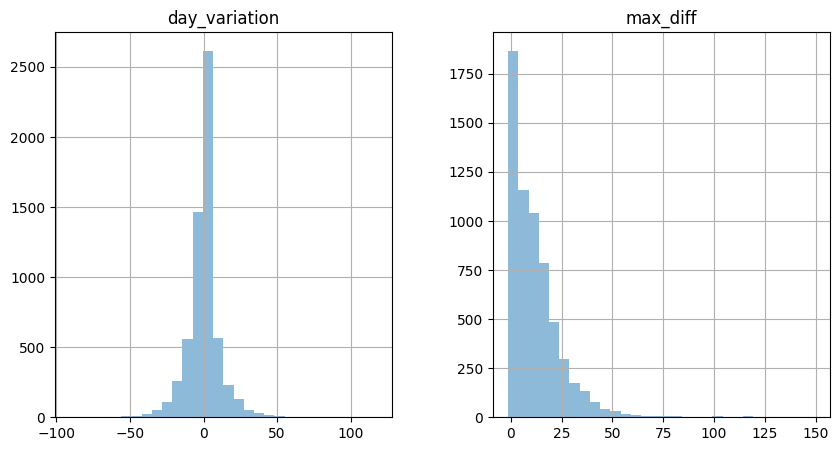

In [12]:
gold[["day_variation", "max_diff"]].hist(bins=30, alpha=0.5, figsize=(10, 5))

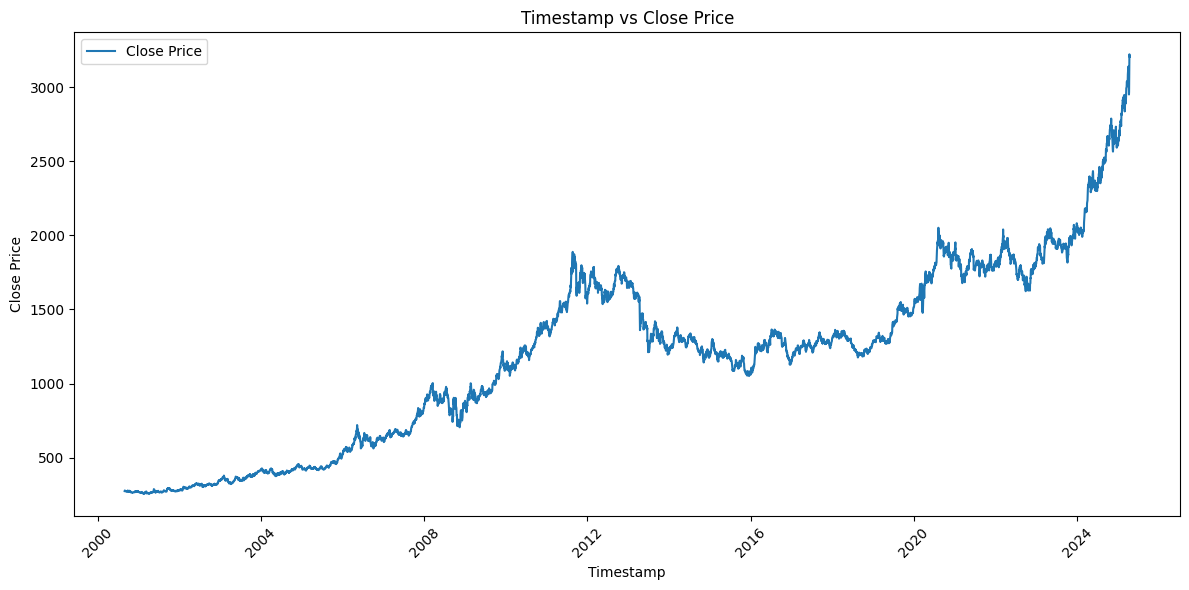

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(gold["timestamp"], gold["close"], label="Close Price")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.title("Timestamp vs Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>],
       [<Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>]], dtype=object)

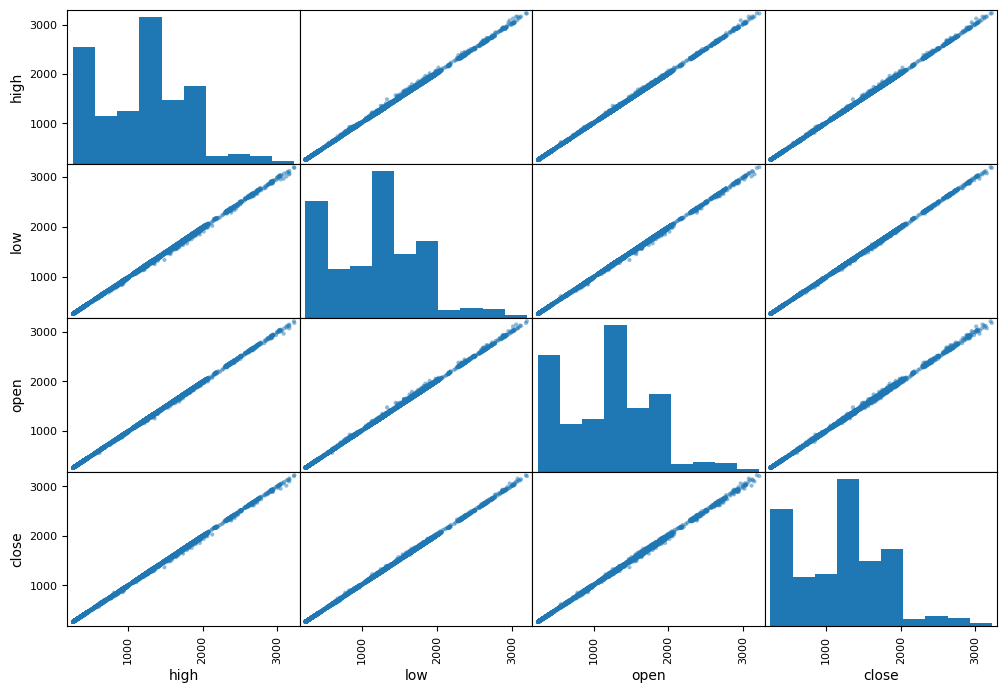

In [14]:
price_cols = ["high", "low", "open", "close"]
scatter_matrix(gold[price_cols], figsize=(12, 8))

In [15]:
gold[price_cols].corr()

,high,low,open,close
high,1.000000,0.999828,0.999906,0.999891
low,0.999828,1.000000,0.999872,0.999916
open,0.999906,0.999872,1.000000,0.999804
close,0.999891,0.999916,0.999804,1.000000


In [16]:
gold["tomorrow_close"] = gold["close"].shift(-1)
gold = gold.dropna(subset=["tomorrow_close"])  # Remove last row with NaN
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,max_diff,tomorrow_close
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.0,0.0,278.3
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,-3.5,3.5,277.0
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.0,0.0,275.8
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,0.0,0.0,274.2
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,0.0,0.0,274.0


<Axes: >

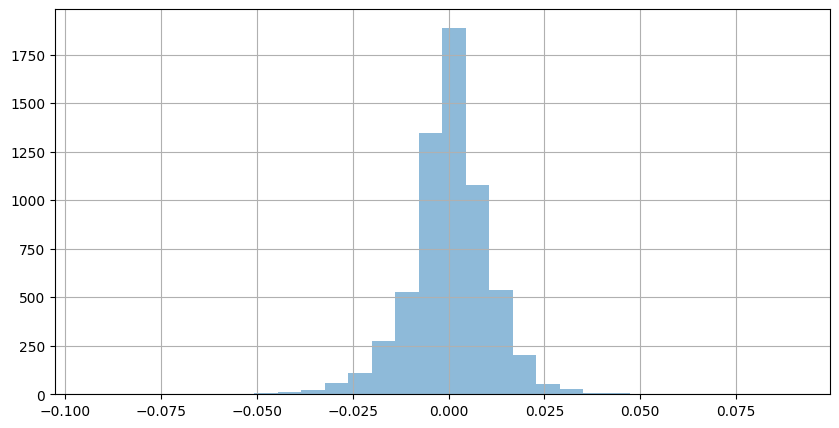

In [17]:
gold["return"] = (gold["tomorrow_close"] - gold["close"]) / gold[
    "close"
]  # return might be our target
gold["return"].hist(bins=30, alpha=0.5, figsize=(10, 5))

In [18]:
value_cols = price_cols + ["return", "max_diff", "day_variation"]

gold[value_cols].describe()

,high,low,open,close,return,max_diff,day_variation
count,6176.000000,6176.000000,6176.000000,6176.000000,6176.000000,6176.000000,6176.000000
mean,1186.622782,1174.558080,1180.687824,1180.684618,0.000457,12.064702,0.003206
std,609.236785,602.403055,605.753395,605.926306,0.010864,13.159610,12.019426
min,256.100000,255.000000,255.000000,255.100000,-0.093538,-1.300000,-90.700000
25%,640.025000,633.875000,636.250000,635.200000,-0.004716,2.500000,-4.000000
50%,1243.850000,1231.700000,1238.150000,1238.350000,0.000475,9.100000,0.000000
75%,1650.850000,1629.650000,1641.225000,1640.075000,0.006237,17.100000,3.400000
max,3235.000000,3182.100000,3182.100000,3222.200000,0.090277,149.400000,117.600000


array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='return', ylabel='high'>,
        <Axes: xlabel='max_diff', ylabel='high'>,
        <Axes: xlabel='day_variation', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='return', ylabel='low'>,
        <Axes: xlabel='max_diff', ylabel='low'>,
        <Axes: xlabel='day_variation', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='return', ylabel='open'>,
        <Axes: xlabel='max_diff', ylabel='open'>,
        <Axes: xlabel='day_variation', ylabel='op

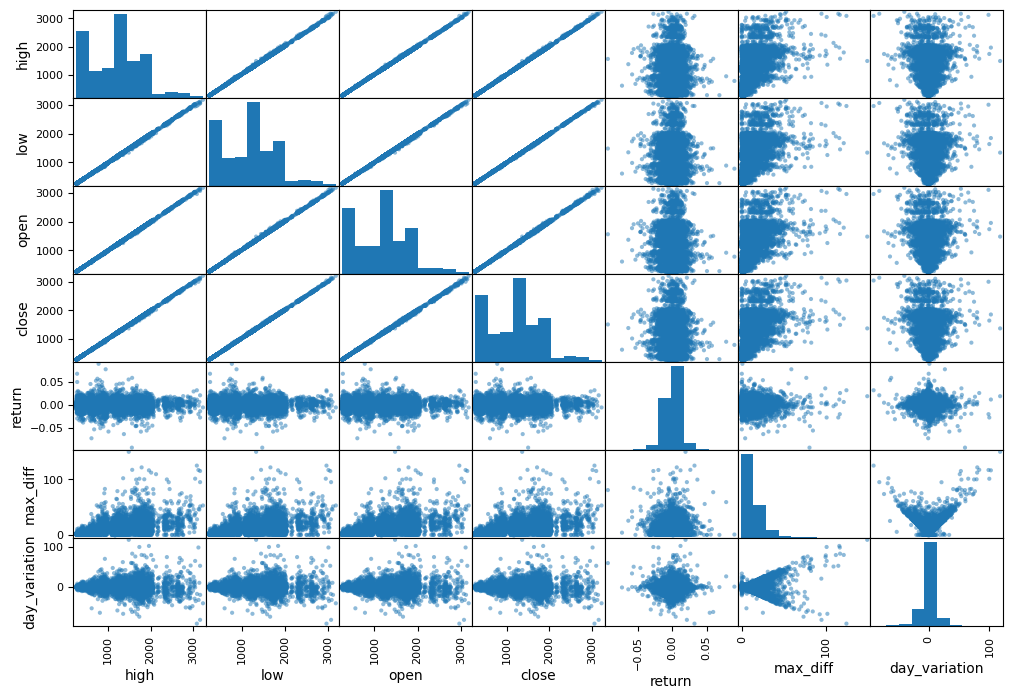

In [19]:
scatter_matrix(gold[value_cols], figsize=(12, 8))

In [20]:
gold[value_cols].corr()

,high,low,open,close,return,max_diff,day_variation
high,1.000000,0.999828,0.999906,0.999891,-0.009729,0.527183,-0.013607
low,0.999828,1.000000,0.999872,0.999916,-0.009529,0.511319,-0.016598
open,0.999906,0.999872,1.000000,0.999803,-0.010067,0.520826,-0.004467
close,0.999891,0.999916,0.999803,1.000000,-0.009952,0.518101,-0.024302
return,-0.009729,-0.009529,-0.010067,-0.009952,1.000000,-0.014177,-0.005646
max_diff,0.527183,0.511319,0.520826,0.518101,-0.014177,1.000000,0.129863
day_variation,-0.013607,-0.016598,-0.004467,-0.024302,-0.005646,0.129863,1.000000


count    6176.000000
mean       13.687662
std         6.856286
min         1.000000
25%         8.000000
50%        14.000000
75%        19.000000
max        35.000000
Name: headlines_count, dtype: float64

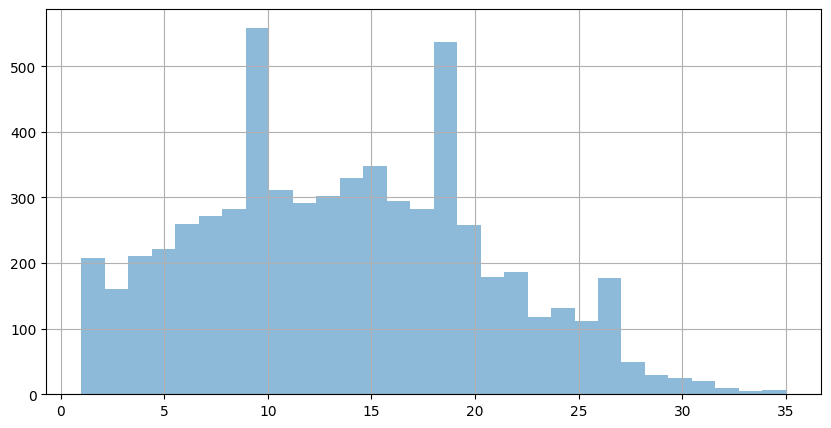

In [21]:
gold["headlines_count"] = gold["headlines"].apply(lambda x: len(x.split("/")))
gold["headlines_count"].hist(bins=30, alpha=0.5, figsize=(10, 5))
gold["headlines_count"].describe()

In [22]:
variances = gold.select_dtypes(include=["float64", "int64"]).var()
for var in variances.index:
    print(f"{var}: {variances[var]:.2f}")

open: 366937.18
high: 371169.46
low: 362889.44
close: 367146.69
volume: 589704091.28
day_variation: 144.47
max_diff: 173.18
tomorrow_close: 367676.79
return: 0.00
headlines_count: 47.01


In [ ]:
def normalize(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()

def min_max_scaling(series: pd.Series) -> pd.Series:
    return (series - series.min()) / (series.max() - series.min())

def log_normalize(series: pd.Series) -> pd.Series:
    return np.log(series.abs() + 1)  # Adding 1 to avoid log(0)

def log_min_max_scaling(series: pd.Series) -> pd.Series:
    return (np.log(series + 1) - np.log(series.min() + 1)) / (
        np.log(series.max() + 1) - np.log(series.min() + 1)
    )  # Adding 1 to avoid log(0)

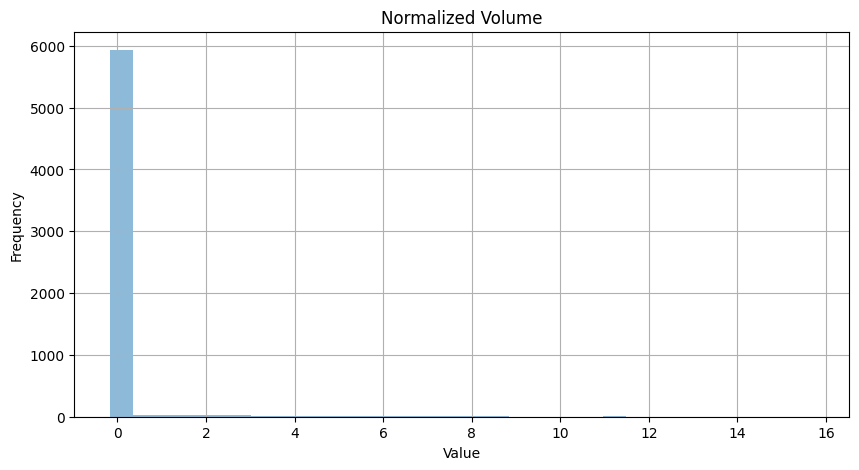

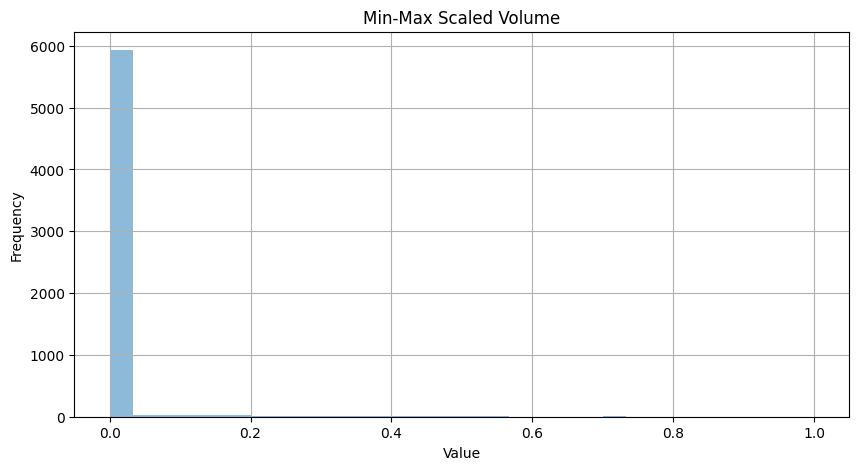

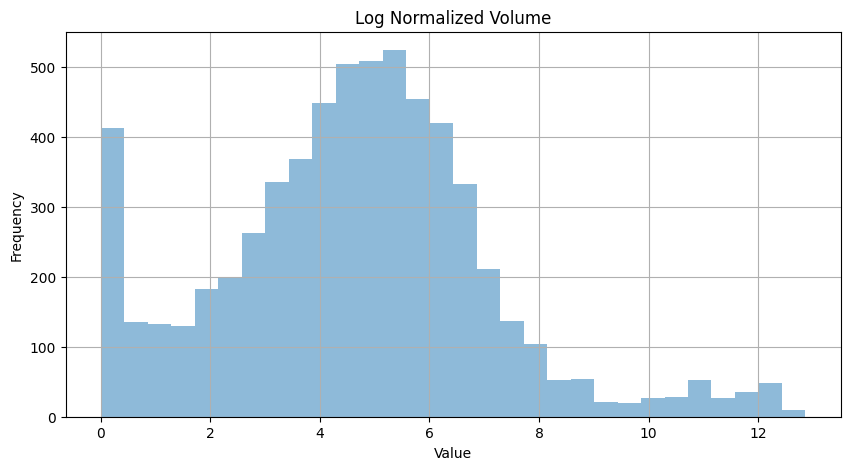

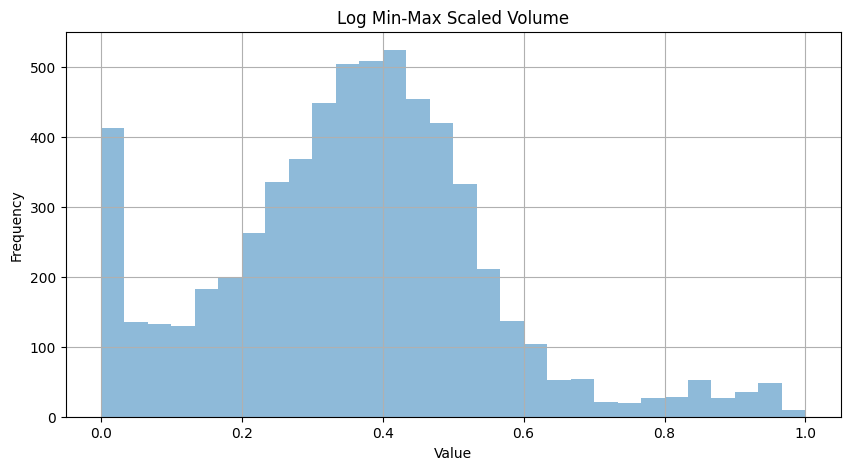

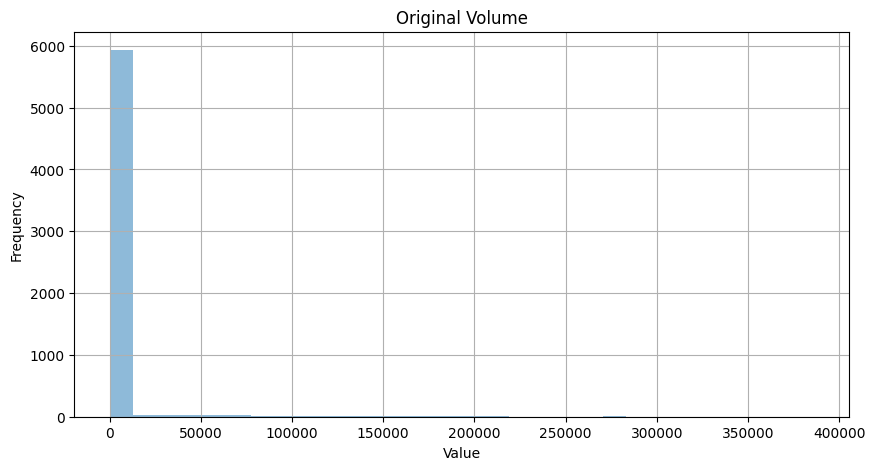

In [24]:
def plot_hist(series: pd.Series, title: str) -> None:
    plt.figure(figsize=(10, 5))
    series.hist(bins=30, alpha=0.5)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

plot_hist(normalize(gold["volume"]), "Normalized Volume")
plot_hist(min_max_scaling(gold["volume"]), "Min-Max Scaled Volume")
plot_hist(log_normalize(gold["volume"]), "Log Normalized Volume")
plot_hist(log_min_max_scaling(gold["volume"]), "Log Min-Max Scaled Volume")
plot_hist(gold["volume"], "Original Volume")

In [25]:
gold["month"] = gold["timestamp"].dt.month
gold["year"] = gold["timestamp"].dt.year
gold = pd.get_dummies(gold, columns=["month", "year"], drop_first=True, dtype=int)
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,...,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,-3.5,...,0,0,0,0,0,0,0,0,0,0
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.0,...,0,0,0,0,0,0,0,0,0,0
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,0.0,...,0,0,0,0,0,0,0,0,0,0
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,0.0,...,0,0,0,0,0,0,0,0,0,0


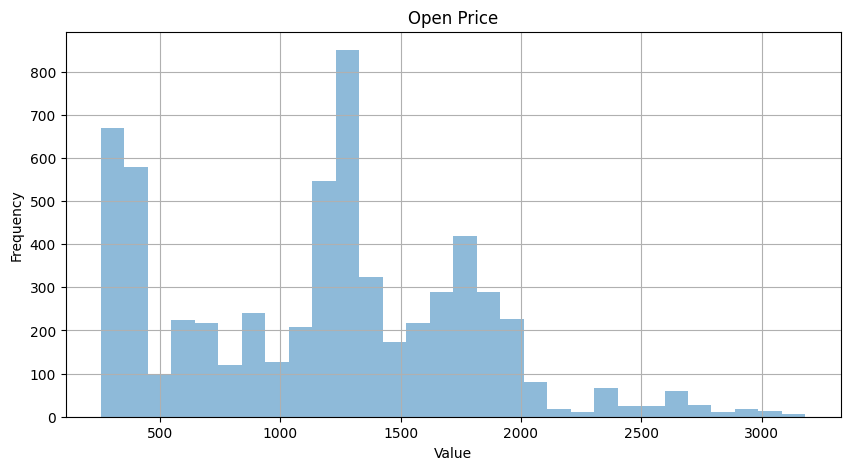

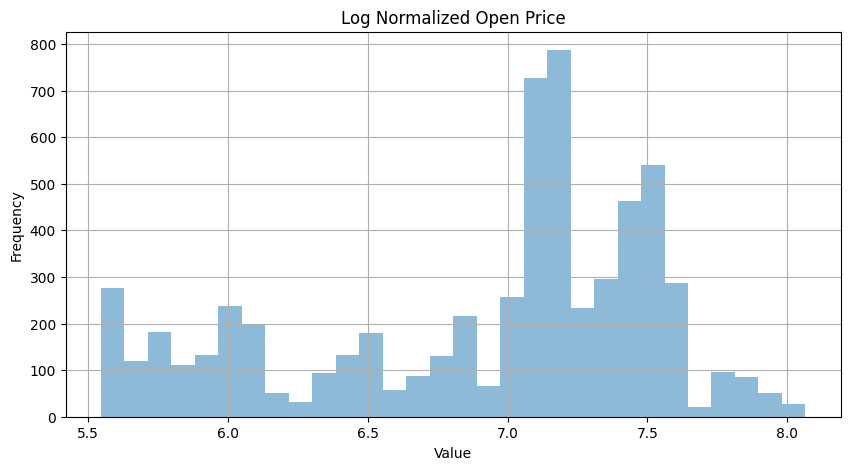

In [26]:
plot_hist(gold["open"], "Open Price")
plot_hist(log_normalize(gold["open"]), "Log Normalized Open Price")

In [ ]:
gold["volume"] = log_normalize(gold["volume"])
# gold["open"] = log_normalize(gold["open"])

In [28]:
# gold["max_diff_positive"] = gold["max_diff"].apply(lambda x: 1 if x > 0 else 0)
# gold["max_diff"] = log_normalize(gold["max_diff"])

In [29]:
# gold["day_variation_positive"] = gold["day_variation"].apply(
#     lambda x: 1 if x > 0 else 0
# )
# gold["day_variation"] = log_normalize(gold["day_variation"])

In [30]:
TARGET = "tomorrow_close"
to_drop = [
    "currency",
    "unit",
    # "day_variation",
    # "max_diff",
    "timestamp",
    "close",
    "return",
    "high",
    "low",
    # "volume",
    # "open",
]

X = gold.drop(columns=to_drop + [TARGET], axis=1)
y = gold[TARGET]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, shuffle=False
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4940, 42), (1236, 42), (4940,), (1236,))

In [32]:
# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)

# y_train = y_train.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)

In [33]:
vectorizer = TfidfVectorizer(
    stop_words="english", max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.8
)
tfidf_vectorized_matrix = vectorizer.fit_transform(X_train["headlines"])
TfidfMatrix = pd.DataFrame(
    tfidf_vectorized_matrix.toarray(), columns=vectorizer.get_feature_names_out()
)  # type: ignore
TfidfMatrix.head()

,000,10,100,11,12,14,15,20,2016,25,...,year high,years,yen,yen euro,yield,yields,york,york city,yuan,zone
0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.000000,0.180674,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.170934
3,0.0,0.197087,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [34]:
sum_words = TfidfMatrix.sum(axis=0)
words_freq = [
    (word, sum_words.iloc[idx]) for word, idx in vectorizer.vocabulary_.items()
]
sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)

In [35]:
# Extract top N words and their frequencies
words = [word for word, _ in sorted_words[:TOP_N]]
frequencies = [freq for _, freq in sorted_words[:TOP_N]]

tfidf_df = pd.DataFrame(
    {
        "word": words,
        "frequency": frequencies,
    }
)
tfidf_df = tfidf_df.sort_values(by="frequency", ascending=False)
tfidf_df.head(TOP_N)

,word,frequency
0,stocks,195.258823
1,new,173.749261
2,dollar,172.040433
3,oil,165.530309
4,trump,142.743382
5,prices,130.053137
6,china,120.134538
7,profit,116.554688
8,deal,114.023632
9,price,109.658944


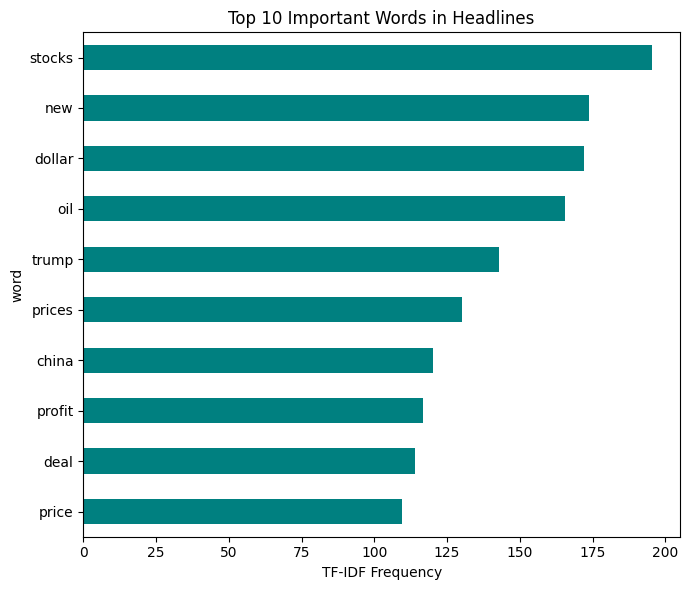

In [36]:
# Plotting using the DataFrame's plot method
tfidf_df.plot(
    x="word",
    y="frequency",
    kind="barh",
    figsize=(7, 6),
    color="teal",
    legend=False,
    title=f"Top {TOP_N} Important Words in Headlines",
)
plt.xlabel("TF-IDF Frequency")
plt.gca().invert_yaxis()  # To have the highest bar at the top
plt.tight_layout()
plt.show()

In [37]:
def contain_word(series: pd.Series, word: str) -> pd.Series:
    """
    Check if a word is contained in the headlines.
    """
    return series.str.contains(word, case=False, na=False).astype(int)

def word_count(series: pd.Series, word: str) -> pd.Series:
    """
    Count the occurrences of a word in the headlines.
    """
    return series.str.lower().str.count(word).fillna(0).astype(int)

In [38]:
for word in tfidf_df["word"]:
    X_train[word] = contain_word(X_train["headlines"], word)
    X_test[word] = contain_word(X_test["headlines"], word)

In [39]:
X_train.drop(columns=["headlines"], inplace=True)
X_test.drop(columns=["headlines"], inplace=True)

In [40]:
X_train.head()

,open,volume,day_variation,max_diff,headlines_count,month_2,month_3,month_4,month_5,month_6,...,stocks,new,dollar,oil,trump,prices,china,profit,deal,price
0,5.616407,0.000000,0.0,0.0,13,0,0,0,0,0,...,1,1,0,0,0,0,0,1,0,0
1,5.619676,0.000000,-3.5,3.5,14,0,0,0,0,0,...,1,0,0,0,0,0,1,1,1,0
2,5.627621,0.000000,0.0,0.0,16,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,5.623295,1.098612,0.0,0.0,9,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,5.617498,0.000000,0.0,0.0,7,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [41]:
timestamp_test = gold["timestamp"].iloc[X_test.index]
timestamp_train = gold["timestamp"].iloc[X_train.index]

last_year_in_training_set = timestamp_train.max().year

filtered_test_set_indexes = (timestamp_test.dt.year > last_year_in_training_set)

X_test = X_test.loc[filtered_test_set_indexes]
y_test = y_test.loc[filtered_test_set_indexes]

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=0.01)
# best value if open is log normalized is 4.3
# otherwise 0.01

In [44]:
model.fit(X_train_scaled, y_train)

Ridge(alpha=10)

In [45]:
y_pred = model.predict(X_test_scaled)

In [46]:
model.score(X_test_scaled, y_test)

0.24429143728763025

In [47]:
rmse = root_mean_squared_error(y_test, y_pred)
print("Square root of RMSE:", rmse)

Square root of RMSE: 305.31172006855417


In [48]:
gold[TARGET].describe()

count    6176.000000
mean     1181.159181
std       606.363581
min       255.100000
25%       635.425000
50%      1238.450000
75%      1640.375000
max      3222.200000
Name: tomorrow_close, dtype: float64

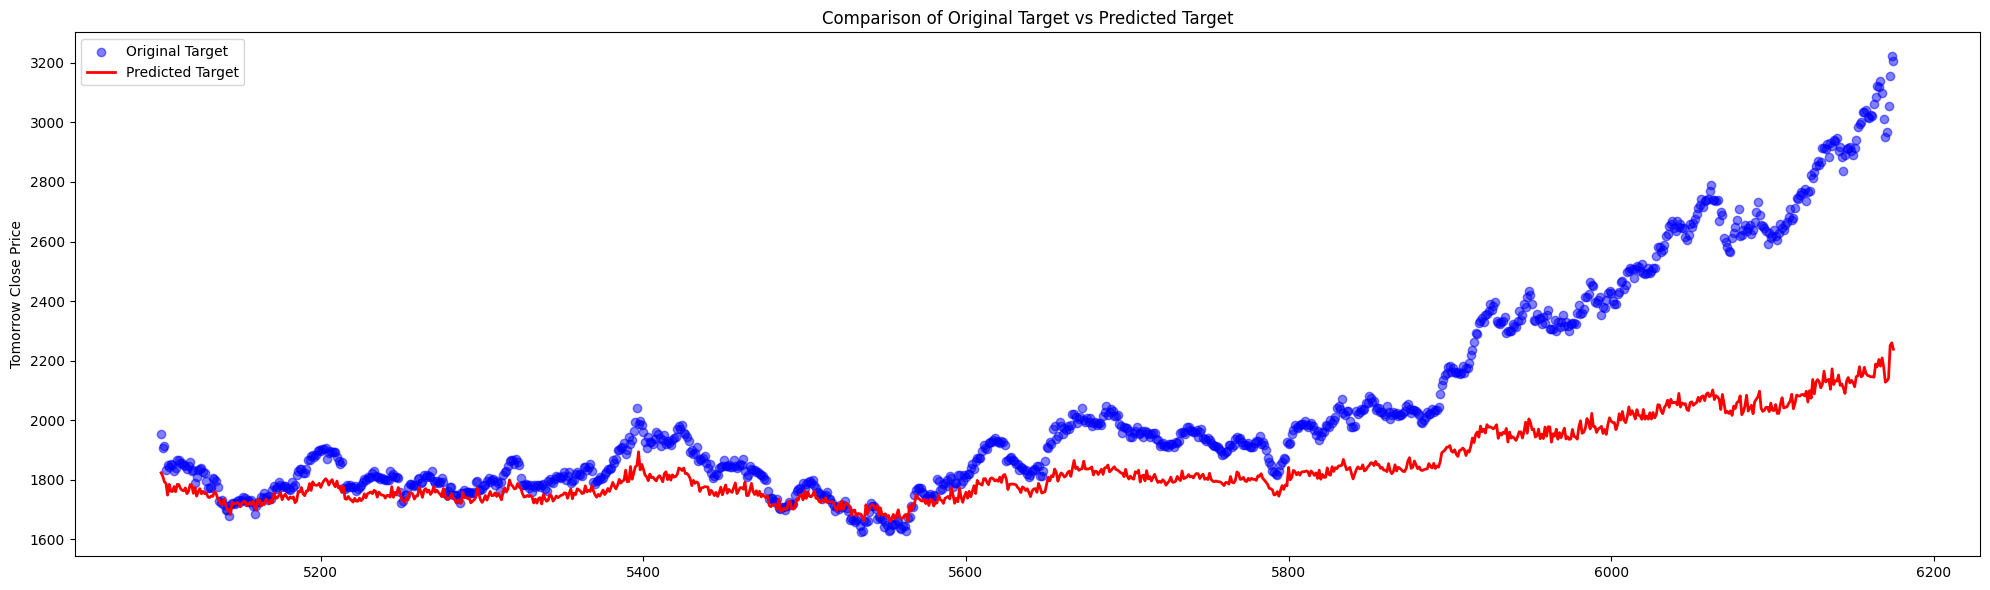

In [49]:
# Plot the original target vs predicted values
plt.figure(figsize=(20, 6))
plt.scatter(
    y_test.index, y_test, label="Original Target", color="blue", alpha=0.5
)
plt.plot(y_test.index, y_pred, label="Predicted Target", color="red", linewidth=2)
plt.ylabel("Tomorrow Close Price")
plt.title("Comparison of Original Target vs Predicted Target")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
diff_df = pd.DataFrame(
    {
        "Original Target": y_test,
        "Predicted Target": y_pred,
        "Difference": y_test - y_pred,
    },
    index=y_test.index,
)
diff_df

,Original Target,Predicted Target,Difference
5101,1952.7,1823.705688,128.994312
5102,1906.9,1812.212103,94.687897
5103,1912.3,1793.581985,118.718015
5104,1834.1,1788.005362,46.094638
5105,1849.6,1748.814226,100.785774
...,...,...,...
6171,2968.4,2132.213582,836.186418
6172,3056.5,2140.293742,916.206258
6173,3155.2,2250.528351,904.671649
6174,3222.2,2260.046118,962.153882


In [51]:
diff_df["Difference"].describe()

count    1075.000000
mean      203.620621
std       227.600697
min       -61.027987
25%        51.202566
50%       116.304659
75%       273.694488
max       966.344754
Name: Difference, dtype: float64

In [52]:
diff_df.var()

Original Target     123462.990377
Predicted Target     15698.146162
Difference           51802.077160
dtype: float64

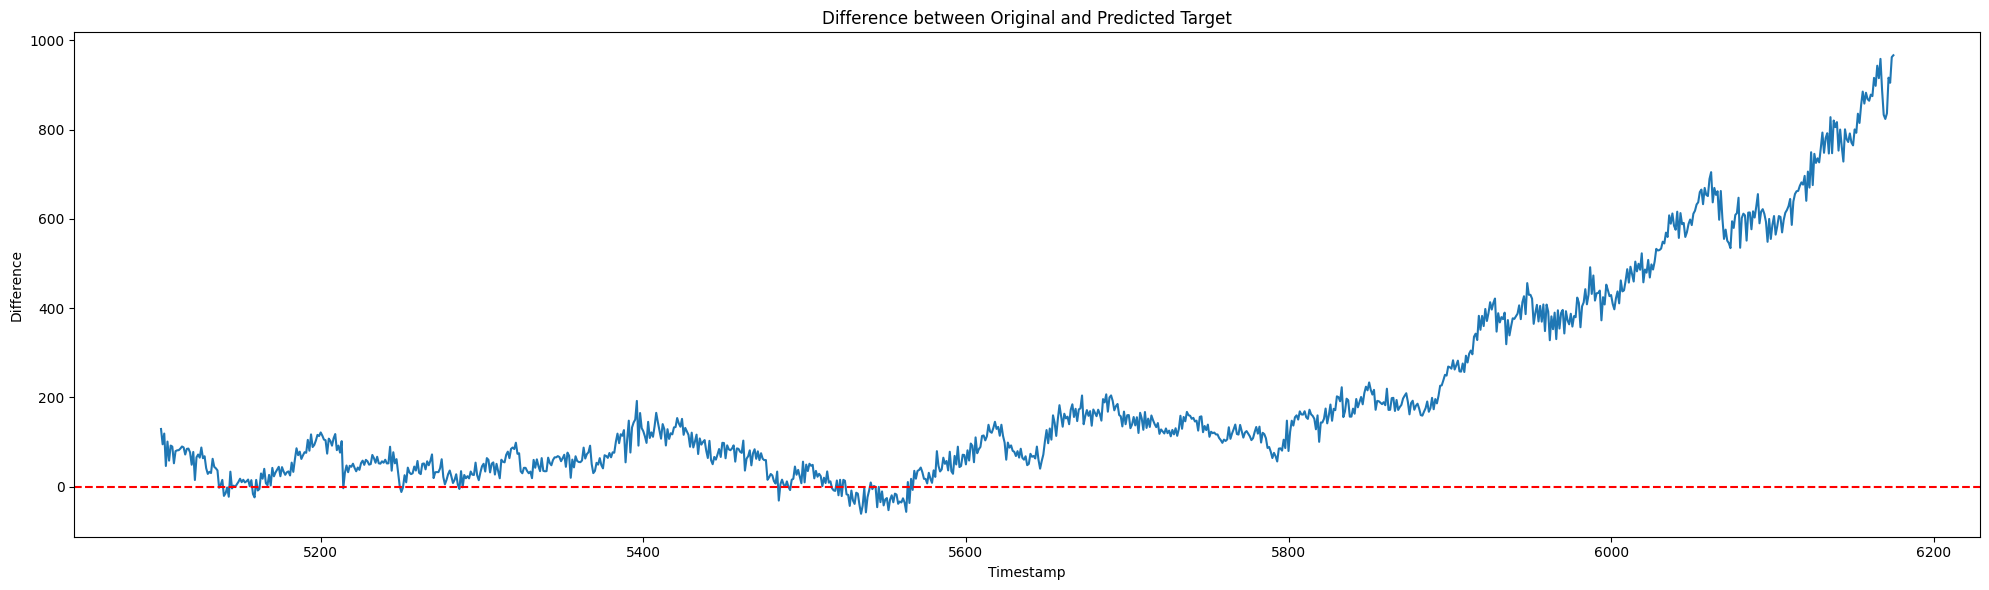

In [53]:
diff_df["Difference"].plot(kind="line", figsize=(20, 6), x_compat=True)
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Difference between Original and Predicted Target")
plt.xlabel("Timestamp")
plt.ylabel("Difference")
plt.tight_layout()
plt.show()

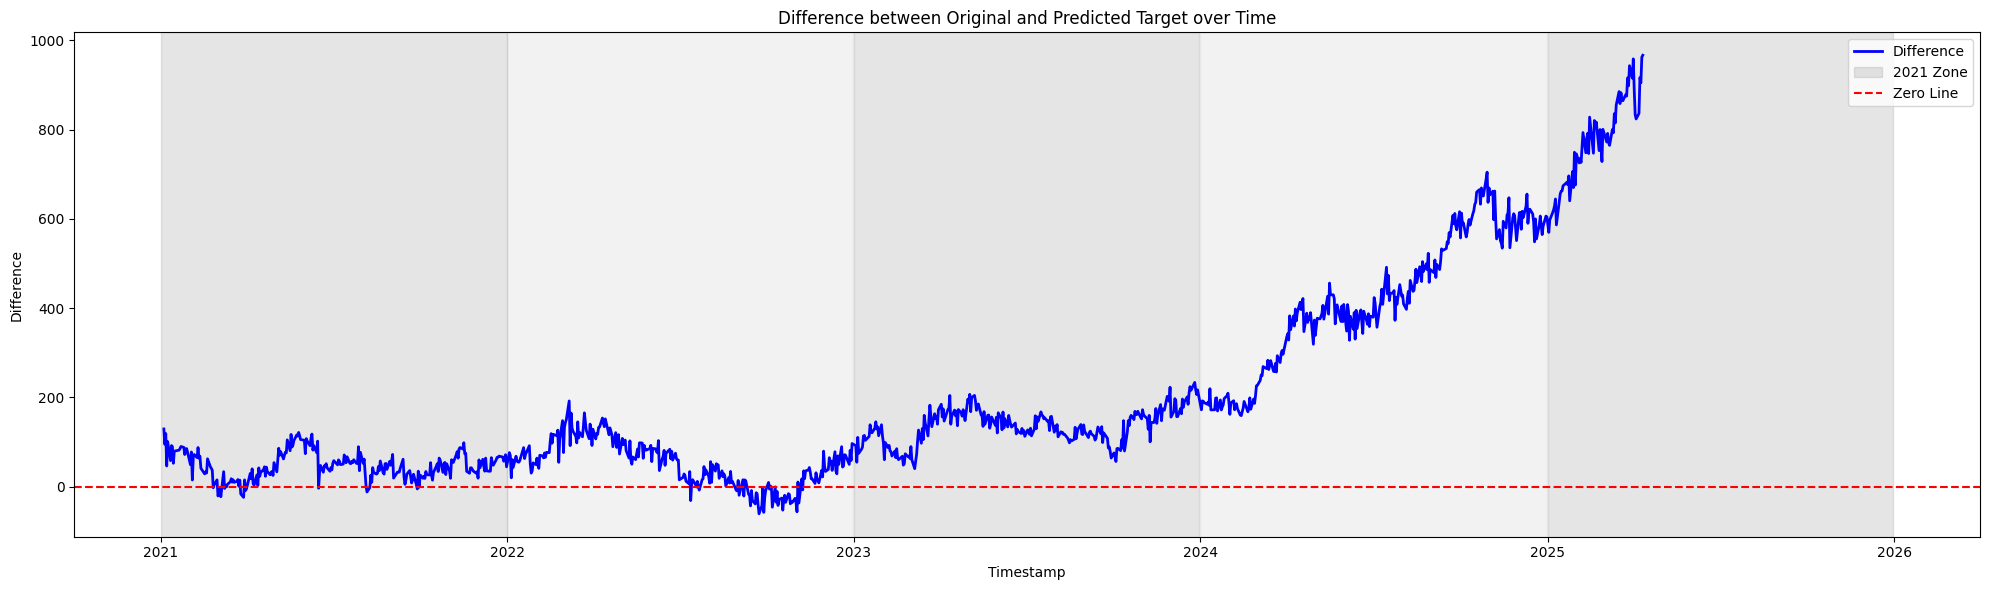

In [54]:
plt.figure(figsize=(20, 6))

# Plot the difference
plt.plot(timestamp_test.loc[filtered_test_set_indexes], diff_df["Difference"], label="Difference", color="blue", linewidth=2)

# Add color zones for each year
unique_years = timestamp_test.loc[filtered_test_set_indexes].dt.year.unique()
for year in unique_years:
    start_date = pd.Timestamp(f"{year}-01-01")
    end_date = pd.Timestamp(f"{year}-12-31")
    plt.axvspan(start_date, end_date, color="gray", alpha=0.1 if year % 2 == 0 else 0.2, label=f"{year} Zone" if year == unique_years[0] else None)

# Add zero line
plt.axhline(y=0, color="red", linestyle="--", label="Zero Line")

# Add labels and title
plt.title("Difference between Original and Predicted Target over Time")
plt.xlabel("Timestamp")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()